The main objective is to analyze the event log data and find the decision places via token replay using alignments beforehand.
But using now our bpmn because of the a lot of skip and tau in the event log that can mislead us.

In [119]:
import sys
import os
import pm4py
import pandas as pd
import numpy as np
import json
import graphviz
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.objects.petri_net.semantics import enabled_transitions, execute
from c45_tree import C45DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [120]:
current_dir = os.getcwd()
sim_core_path = os.path.abspath(os.path.join(current_dir, '..', 'sim_core'))
if sim_core_path not in sys.path:
    sys.path.append(sim_core_path)
try:
    from pn_model import PNModel, wrap_net
    from bpmn_io import read_bpmn
except ImportError as e:
    print(f"Error: {e}")

In [121]:
bpmn_path = "../data/process_model.bpmn"
log_path = "../data/BPI Challenge 2017.xes.gz"

In [122]:
log = pm4py.read_xes(log_path)

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:37<00:00, 838.58it/s] 


In [123]:
bpmn_graph = pm4py.read_bpmn(bpmn_path)

In [124]:
log_activities = set(log['concept:name'].unique())
bpmn_labels = set()
for node in bpmn_graph.get_nodes():
    if node.get_name() and node.get_name().strip() != "":
        bpmn_labels.add(node.get_name().strip())

missing_in_bpmn = log_activities - bpmn_labels
missing_in_bpmn

{'O_Sent (online only)',
 'W_Assess potential fraud',
 'W_Personal Loan collection',
 'W_Shortened completion '}

It is normal to get such as average fitness because as we discovered: we didnt model these activites in our bpmn 'O_Sent (online only)',
 'W_Assess potential fraud',
 'W_Personal Loan collection',
 'W_Shortened completion '
Otherwise, the data would be too noisy

Decided to the training with event log 

In [125]:
df = pm4py.convert_to_dataframe(log)
print(f"Loaded {len(df)} events.")
df_log = pm4py.convert_to_dataframe(log)
df_log['time:timestamp'] = pd.to_datetime(df_log['time:timestamp'])
df_log = df_log.sort_values(['case:concept:name', 'time:timestamp'])

Loaded 1202267 events.


## Case Attributes

In [126]:

#  Build case attribute lookup from event log
case_attr_cols = ["case:concept:name", "case:LoanGoal", "case:ApplicationType", "case:RequestedAmount"]
available_cols = [c for c in case_attr_cols if c in df_log.columns]
case_attrs = df_log.groupby("case:concept:name").first()[available_cols[1:]].reset_index()
case_attrs.columns = ["case_id", "loan_goal", "application_type", "requested_amount"]
case_attrs["loan_goal"] = case_attrs["loan_goal"].fillna("Unknown").astype(str)
case_attrs["application_type"] = case_attrs["application_type"].fillna("Unknown").astype(str)
case_attrs["requested_amount"] = pd.to_numeric(case_attrs["requested_amount"], errors="coerce").fillna(0)

# Amount category
case_attrs["amount_category"] = pd.cut(
    case_attrs["requested_amount"],
    bins=[0, 5000, 10000, 20000, 50000, float("inf")],
    labels=["very_low", "low", "medium", "high", "very_high"]
).astype(str)

case_lookup = case_attrs.set_index("case_id").to_dict("index")
print(f"Case attributes loaded for {len(case_lookup)} cases.")
print(f"LoanGoal dist: {case_attrs['loan_goal'].value_counts().to_dict()}")
print(f"Amount dist:   {case_attrs['amount_category'].value_counts().to_dict()}")

# Build CreditScore lookup per offer event
# CreditScore is on O_Create Offer events — extract max per case
offer_events = df_log[df_log["concept:name"] == "O_Create Offer"].copy()
credit_cols = [c for c in ["CreditScore", "OfferedAmount"] if c in offer_events.columns]
if credit_cols:
    case_credit = offer_events.groupby("case:concept:name")[credit_cols].max().reset_index()
    case_credit.columns = ["case_id"] + credit_cols
    for _, row in case_credit.iterrows():
        cid = row["case_id"]
        if cid in case_lookup:
            if "CreditScore" in credit_cols:
                cs = row.get("CreditScore", None)
                if pd.notna(cs):
                    cs = float(cs)
                    if cs > 800: case_lookup[cid]["credit_score_bin"] = "excellent"
                    elif cs > 600: case_lookup[cid]["credit_score_bin"] = "good"
                    elif cs > 400: case_lookup[cid]["credit_score_bin"] = "fair"
                    else: case_lookup[cid]["credit_score_bin"] = "poor"
    print("CreditScore extracted from offer events.")
else:
    print("No CreditScore/OfferedAmount columns found.")

Case attributes loaded for 31509 cases.
LoanGoal dist: {'Car': 9328, 'Home improvement': 7669, 'Existing loan takeover': 5601, 'Other, see explanation': 2985, 'Unknown': 2365, 'Not speficied': 1065, 'Remaining debt home': 842, 'Extra spending limit': 625, 'Caravan / Camper': 369, 'Motorcycle': 275, 'Boat': 201, 'Tax payments': 152, 'Business goal': 30, 'Debt restructuring': 2}
Amount dist:   {'medium': 9013, 'high': 7212, 'low': 7081, 'very_low': 4279, np.str_('nan'): 3080, 'very_high': 844}
CreditScore extracted from offer events.


In [127]:
tree = inductive_miner.apply(log)

net, initial_marking, final_marking = pt_converter.apply(tree)

In [128]:
replayed_log = token_replay.apply(log, net, initial_marking, final_marking)

replaying log with TBR, completed traces :: 100%|██████████| 15930/15930 [01:10<00:00, 225.16it/s]


In [129]:
event_log = pm4py.convert_to_event_log(log)

(skip_37, None),(skip_38, None),(tauSplit_40, None),(skip_48, None), etc. are the silent transitions that probably lead to a XOR

In [130]:
decision_training_data = []

for trace_idx, trace in enumerate(event_log):
    replay_result = replayed_log[trace_idx]
    fired_transitions = replay_result['activated_transitions']
    event_idx = 0

    case_id = trace.attributes.get('concept:name')
    case_start_time = trace[0]['time:timestamp']
    current_marking = initial_marking.copy()

    # case-level attributes from lookup
    c_info = case_lookup.get(case_id, {})
    loan_goal = c_info.get("loan_goal", "Unknown")
    app_type = c_info.get("application_type", "Unknown")
    amount_cat = c_info.get("amount_category", "medium")
    credit_bin = c_info.get("credit_score_bin", "unknown")

    # per-case tracking
    activity_counts = {}
    offer_count = 0
    rejection_count = 0
    accepted_offer = False

    for t in fired_transitions:
        enabled = enabled_transitions(net, current_marking)

        if len(enabled) > 1:
            if event_idx > 0 and event_idx < len(trace):
                prev_event = trace[event_idx - 1]
                curr_event = trace[event_idx]

                decision_label = t.label if t.label else t.name
                prev_act = prev_event['concept:name']
                prev_act_2 = trace[event_idx - 2]['concept:name'] if event_idx > 1 else "START"

                features = {
                    "case_id": case_id,
                    "prev_activity": prev_act,
                    "prev_activity_2": prev_act_2,
                    "last_resource": prev_event.get('org:resource', 'System'),
                    "last_duration": (curr_event['time:timestamp'] - prev_event['time:timestamp']).total_seconds(),
                    "case_duration_hours": (curr_event['time:timestamp'] - case_start_time).total_seconds() / 3600,
                    "event_index": event_idx,
                    "target_decision": decision_label,
                    "loan_goal": loan_goal,
                    "application_type": app_type,
                    "amount_category": amount_cat,
                    "credit_score_bin": credit_bin,
                    "offer_count": offer_count,
                    "has_rejection": 1 if rejection_count > 0 else 0,
                    "has_accepted_offer": 1 if accepted_offer else 0,
                    "is_repeated": str(activity_counts.get(prev_act, 0) > 1),
                }
                decision_training_data.append(features)

        # State update
        current_marking = execute(t, net, current_marking)

        if t.label is not None:
            act_name = t.label
            activity_counts[act_name] = activity_counts.get(act_name, 0) + 1

            # track business events
            if act_name in ("O_Created", "O_Create Offer"):
                offer_count += 1
            if act_name in ("O_Refused", "O_Cancelled", "A_Denied", "A_Cancelled"):
                rejection_count += 1
            if act_name == "O_Accepted":
                accepted_offer = True

            event_idx += 1

df_xor_decisions = pd.DataFrame(decision_training_data)

print(f"Total Decision Rows: {len(df_xor_decisions)}")
print(f"Unique Previous Activities: {df_xor_decisions['prev_activity'].nunique()}")
print(f"Unique Target Decisions: {df_xor_decisions['target_decision'].nunique()}")

Total Decision Rows: 2819057
Unique Previous Activities: 26
Unique Target Decisions: 83


In [131]:
df_xor_decisions.head()

,case_id,prev_activity,prev_activity_2,last_resource,last_duration,case_duration_hours,event_index,target_decision,loan_goal,application_type,amount_category,credit_score_bin,offer_count,has_rejection,has_accepted_offer,is_repeated
0,Application_652823628,A_Create Application,START,User_1,0.048,0.000013,1,A_Submitted,Existing loan takeover,New credit,medium,excellent,0,0,0,False
1,Application_652823628,A_Submitted,A_Create Application,User_1,0.422,0.000131,2,init_loop_11,Existing loan takeover,New credit,medium,excellent,0,0,0,False
2,Application_652823628,A_Submitted,A_Create Application,User_1,0.422,0.000131,2,W_Handle leads,Existing loan takeover,New credit,medium,excellent,0,0,0,False
3,Application_652823628,W_Handle leads,A_Submitted,User_1,80.618,0.022524,3,skip_13,Existing loan takeover,New credit,medium,excellent,0,0,0,False
4,Application_652823628,W_Handle leads,A_Submitted,User_1,80.618,0.022524,3,W_Handle leads,Existing loan takeover,New credit,medium,excellent,0,0,0,False


In [132]:
# Target Activities with silent transitions
print(df_xor_decisions['target_decision'].value_counts().head(30))

target_decision
W_Call after offers         179625
skip_25                     148742
W_Complete application      147848
skip_65                     134654
W_Validate application      117067
skip_72                     116345
skip_35                      88572
skip_70                      87475
skip_19                      84588
tauSplit_40                  77274
W_Call incomplete files      71866
tauJoin_41                   69808
skip_36                      69313
skip_48                      64408
skip_39                      63326
tauSplit_20                  63003
skip_42                      62594
init_loop_29                 60428
skip_45                      58850
init_loop_33                 47754
W_Handle leads               47208
skip_71                      47179
skip_37                      41980
skip_38                      41936
O_Create Offer               40923
O_Created                    40724
skip_31                      39376
O_Sent (mail and online)     37983
skip

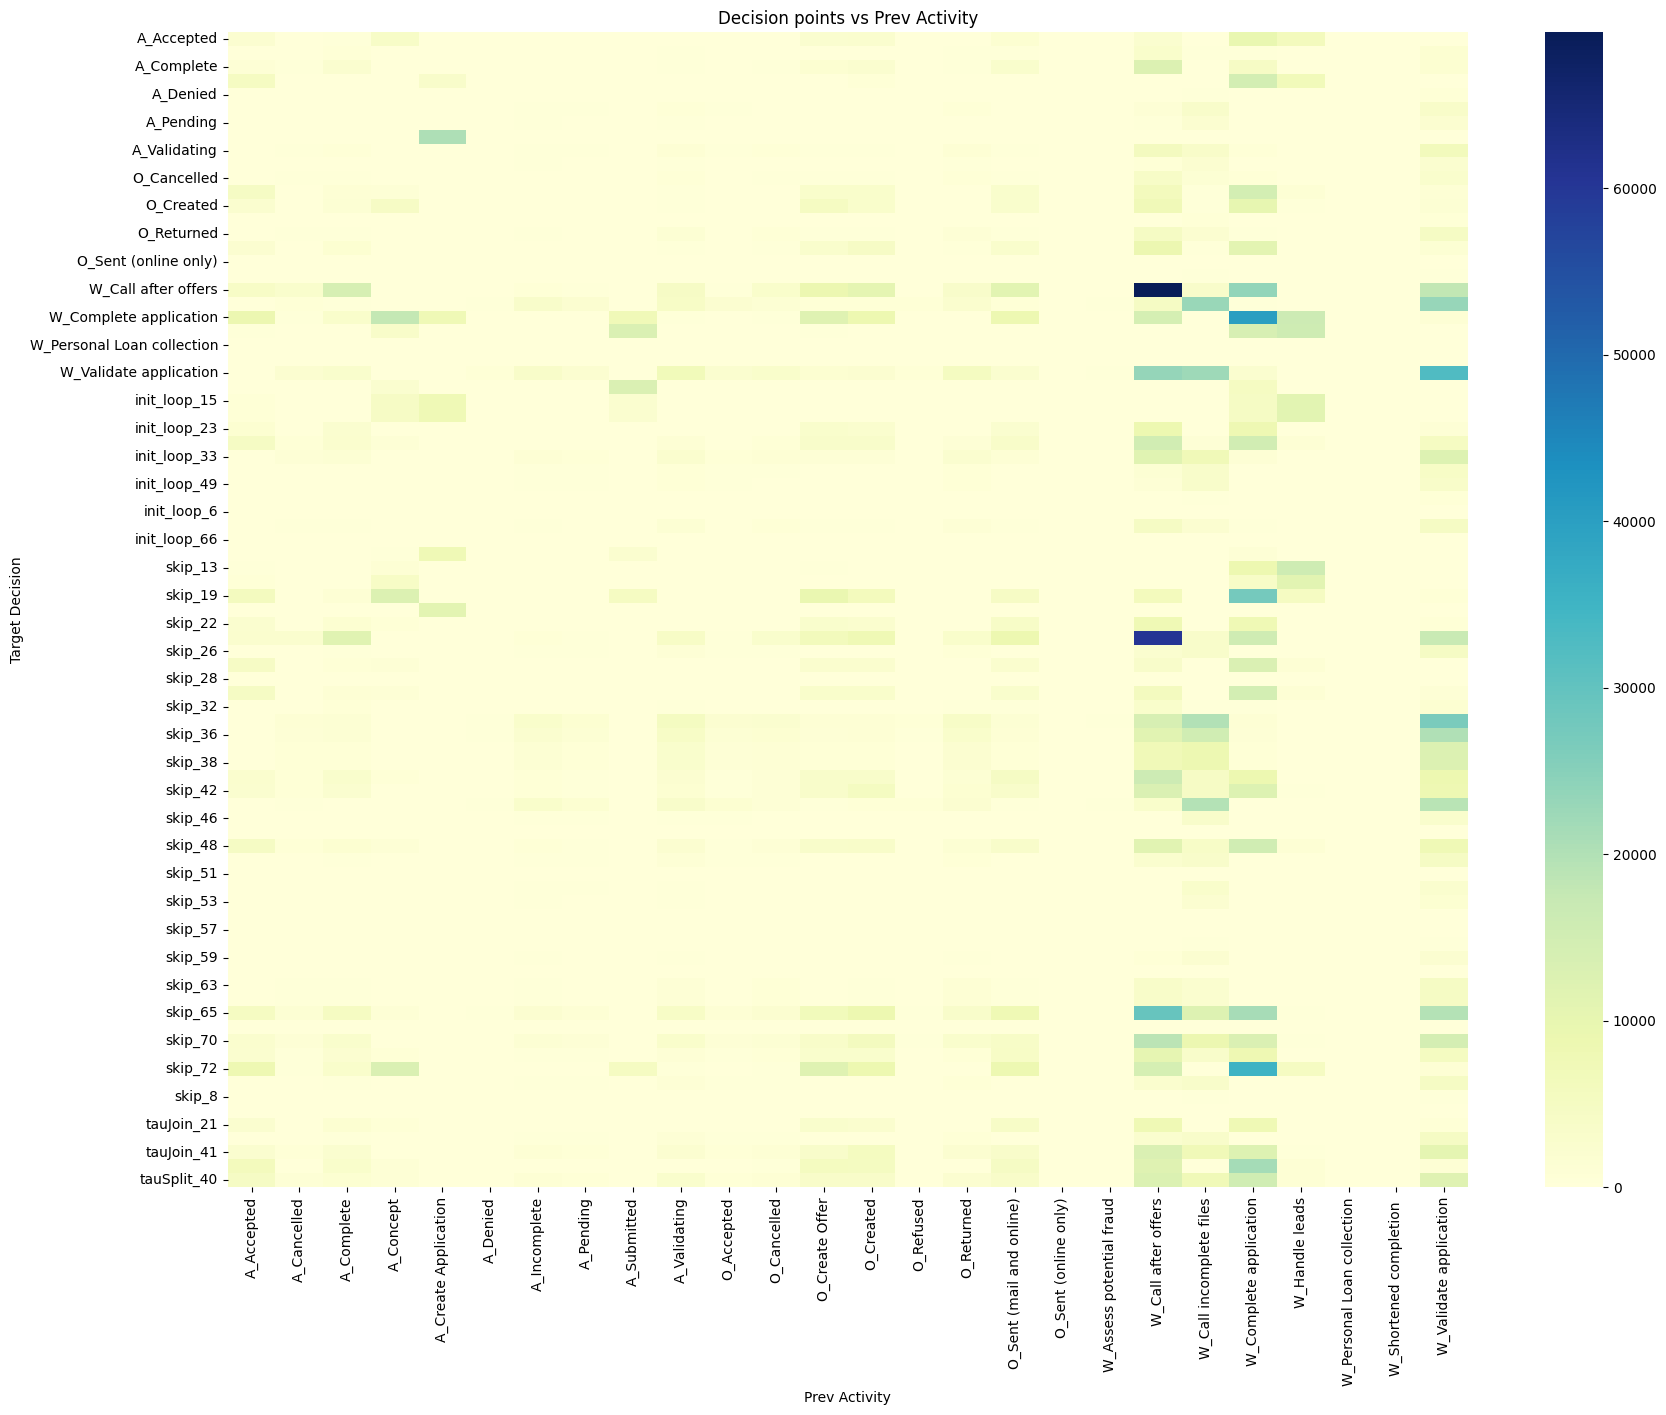

In [133]:
matrix_view = pd.crosstab(df_xor_decisions['target_decision'], df_xor_decisions['prev_activity'])

plt.figure(figsize=(20, 15))
sns.heatmap(matrix_view, cmap="YlGnBu", annot=False)
plt.title("Decision points vs Prev Activity")
plt.xlabel("Prev Activity")
plt.ylabel("Target Decision")
plt.show()

## Cleaning

In [134]:
df_clean = df_xor_decisions[
    (df_xor_decisions['target_decision'].notna()) &
    (df_xor_decisions['target_decision'] != "") &
    (~df_xor_decisions['target_decision'].str.contains('tau|skip|init|loop', case=False))
].copy()

In [135]:
# Save df_clean for use in decision_evaluation.ipynb as ground-truth XOR decision reference
# Self-loops (prev_activity == target_decision) are excluded — they are not real routing choices
df_clean_xor = df_clean[
    df_clean["prev_activity"] != df_clean["target_decision"]
][["prev_activity", "target_decision"]]

df_clean_xor.to_csv("df_clean_xor.csv", index=False)
print(f"Saved df_clean_xor.csv: {len(df_clean_xor)} XOR decision records (self-loops excluded), "
      f"{df_clean_xor['prev_activity'].nunique()} unique prev_activities")


Saved df_clean_xor.csv: 693735 XOR decision records (self-loops excluded), 26 unique prev_activities


In [136]:
counts = df_clean['target_decision'].value_counts()
significant_targets = counts[counts > 50].index
df_clean = df_clean[df_clean['target_decision'].isin(significant_targets)]
print(f"After filtering: {len(df_clean):,} rows, {df_clean['target_decision'].nunique()} targets")
print(df_clean['target_decision'].value_counts())

After filtering: 891,414 rows, 24 targets
target_decision
W_Call after offers         179625
W_Complete application      147848
W_Validate application      117067
W_Call incomplete files      71866
W_Handle leads               47208
O_Create Offer               40923
O_Created                    40724
O_Sent (mail and online)     37983
A_Concept                    31502
A_Accepted                   31417
A_Complete                   30491
A_Validating                 23603
A_Submitted                  20423
O_Returned                   17418
O_Cancelled                  12968
A_Incomplete                 11077
A_Cancelled                   8653
O_Accepted                    7021
A_Pending                     6663
O_Refused                     2199
A_Denied                      1952
W_Assess potential fraud      1336
O_Sent (online only)          1213
W_Shortened completion         234
Name: count, dtype: int64


In [137]:
# How many unique target decisions exist per prev_activity?
# If average is 3-5, per-activity C4.5 ensemble would dramatically simplify the problem
targets_per_activity = (
    df_clean.groupby("prev_activity")["target_decision"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
targets_per_activity.columns = ["prev_activity", "unique_targets"]

# Also show the actual class distribution per activity
sample_counts = df_clean.groupby("prev_activity")["target_decision"].count().rename("total_samples")
targets_per_activity = targets_per_activity.merge(sample_counts, on="prev_activity")

print(f"Average unique targets per prev_activity: {targets_per_activity['unique_targets'].mean():.1f}")
print(f"Max: {targets_per_activity['unique_targets'].max()}  "
      f"Min: {targets_per_activity['unique_targets'].min()}")
print(f"\nGlobal model: 24-class problem")
print(f"Per-activity model: avg {targets_per_activity['unique_targets'].mean():.1f}-class problem\n")
print(targets_per_activity.to_string(index=False))

Average unique targets per prev_activity: 19.5
Max: 23  Min: 2

Global model: 24-class problem
Per-activity model: avg 19.5-class problem

             prev_activity  unique_targets  total_samples
                A_Accepted              23          31408
              A_Validating              23          22734
    W_Complete application              23         147375
   W_Call incomplete files              23          67297
       W_Call after offers              23         169370
      O_Sent (online only)              23           1204
  O_Sent (mail and online)              23          37754
            O_Create Offer              23          40813
               O_Cancelled              23          11502
                 O_Created              23          40555
                A_Complete              23          30185
    W_Validate application              23         106438
               A_Cancelled              22           8366
                O_Returned              22       

# Binning

In [138]:
df_clean['duration_bin'], duration_bins = pd.qcut(
    df_clean['last_duration'], q=5,
    labels=['VeryShort', 'Short', 'Medium', 'Long', 'VeryLong'],
    duplicates='drop', retbins=True
)

df_clean['case_age_category'], case_age_bins = pd.qcut(
    df_clean['case_duration_hours'], q=4,
    labels=['Very_New', 'New', 'Old', 'Delayed'],
    duplicates='drop', retbins=True
)

# Granular offer_category: loop-breaking signal for C4.5
df_clean['offer_category'] = df_clean['offer_count'].apply(
    lambda x: 'none' if x == 0
    else 'single'   if x == 1
    else 'two'      if x == 2
    else 'three'    if x == 3
    else 'many'                   # 4+ offers → strong signal to exit loop
)

# Reduce prev_activity_2 cardinality: 25 unique values → 5 groups
# This increases gain ratio so C4.5 actually uses the feature
_OFFER_LIFECYCLE = {
    'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Sent (online only)',
    'O_Accepted', 'O_Cancelled', 'O_Returned', 'O_Refused'
}
_APP_DECISION = {
    'A_Accepted', 'A_Concept', 'A_Complete', 'A_Validating',
    'A_Incomplete', 'A_Cancelled', 'A_Denied', 'A_Pending'
}
_WORKFLOW = {
    'W_Complete application', 'W_Validate application', 'W_Call after offers',
    'W_Call incomplete files', 'W_Handle leads', 'W_Assess potential fraud',
    'W_Shortened completion ', 'W_Personal Loan collection'
}
_CASE_START = {'A_Create Application', 'A_Submitted'}

def _group_activity(act):
    if act == 'START':          return 'start'
    if act in _OFFER_LIFECYCLE: return 'offer'
    if act in _APP_DECISION:    return 'app_decision'
    if act in _WORKFLOW:        return 'workflow'
    if act in _CASE_START:      return 'case_start'
    return 'other'

df_clean['prev_activity_2_group'] = df_clean['prev_activity_2'].apply(_group_activity)

print("Feature distributions:")
for col in ['loan_goal', 'amount_category', 'credit_score_bin', 'offer_category',
            'has_rejection', 'has_accepted_offer', 'is_repeated', 'prev_activity_2_group']:
    print(f"  {col}: {df_clean[col].value_counts().to_dict()}")

Feature distributions:
  loan_goal: {'Car': 259724, 'Home improvement': 219048, 'Existing loan takeover': 162789, 'Other, see explanation': 83393, 'Unknown': 64244, 'Not speficied': 30452, 'Remaining debt home': 25948, 'Extra spending limit': 17112, 'Caravan / Camper': 10173, 'Motorcycle': 7579, 'Boat': 5704, 'Tax payments': 4377, 'Business goal': 833, 'Debt restructuring': 38}
  amount_category: {'medium': 256514, 'high': 207321, 'low': 199744, 'very_low': 118506, np.str_('nan'): 84585, 'very_high': 24744}
  credit_score_bin: {'poor': 407556, 'excellent': 398522, 'good': 84766, 'fair': 570}
  offer_category: {'two': 462138, 'none': 277177, 'many': 113337, 'single': 31344, 'three': 7418}
  has_rejection: {0: 849429, 1: 41985}
  has_accepted_offer: {0: 877196, 1: 14218}
  is_repeated: {'False': 530877, 'True': 360537}
  prev_activity_2_group: {'workflow': 527023, 'offer': 145516, 'app_decision': 135434, 'case_start': 51932, 'start': 31509}


## Train the tree C4.5

In [139]:
features = [
    "prev_activity",        
    "prev_activity_2_group",   # grouped: offer / app_decision / workflow / case_start / start
    "duration_bin",         
    "case_age_category",    
    "loan_goal",            
    "application_type",     
    "amount_category",      
    "credit_score_bin",     
    "offer_category",       
    "has_rejection",        
    "has_accepted_offer",   
    "is_repeated",          
]

attribute_types = {f: "nominal" for f in features}

X = df_clean[features].astype(str)
y = df_clean["target_decision"]

In [140]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

MIN_SUPPORT = 100

trees_dict     = {}
activity_results = []

for activity in sorted(df_clean['prev_activity'].unique()):
    df_act = df_clean[df_clean['prev_activity'] == activity]
    y_act  = df_act['target_decision']
    X_act  = df_act[features].astype(str)

    # Drop low-support classes within this activity
    class_counts  = y_act.value_counts()
    valid_classes = class_counts[class_counts >= MIN_SUPPORT].index
    mask          = y_act.isin(valid_classes)
    X_act, y_act  = X_act[mask], y_act[mask]

    if len(y_act) < MIN_SUPPORT or y_act.nunique() < 2:
        print(f"  SKIP {activity}: {len(y_act)} rows, {y_act.nunique() if len(y_act) else 0} classes")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_act, y_act, test_size=0.2, random_state=42, stratify=y_act
    )

    tree = C45DecisionTree(attribute_types=attribute_types, max_depth=10, min_samples_split=50,
                           min_samples_leaf=20, min_gain_ratio=0.01)
    tree.fit(X_train, y_train)

    y_pred_train = pd.Series([tree.predict_one(row) for _, row in X_train.iterrows()], index=X_train.index)
    train_acc    = accuracy_score(y_train, y_pred_train)

    y_pred  = pd.Series([tree.predict_one(row) for _, row in X_test.iterrows()], index=X_test.index)
    acc     = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    trees_dict[activity] = tree
    activity_results.append({
        "activity":  activity,
        "n_classes": y_act.nunique(),
        "n_train":   len(X_train),
        "n_test":    len(X_test),
        "train_acc": round(train_acc, 4),
        "acc":       round(acc, 4),
        "bal_acc":   round(bal_acc, 4),
        "overfit":   round(train_acc - acc, 4),
    })
    print(f"  {activity}: {y_act.nunique()} classes  train={train_acc:.4f}  acc={acc:.4f}  bal={bal_acc:.4f}  overfit={train_acc-acc:+.4f}")

df_results = pd.DataFrame(activity_results).sort_values("acc", ascending=False)
print(f"\nTrained {len(trees_dict)} activity-specific trees")
print(f"Mean accuracy (weighted): {(df_results['acc'] * df_results['n_test']).sum() / df_results['n_test'].sum():.4f}")
print(f"\n{df_results.to_string(index=False)}")


  A_Accepted: 10 classes  train=0.5375  acc=0.5436  bal=0.3826  overfit=-0.0060
  A_Cancelled: 13 classes  train=0.3765  acc=0.3673  bal=0.1683  overfit=+0.0092
  A_Complete: 13 classes  train=0.5607  acc=0.5652  bal=0.2432  overfit=-0.0046
  A_Concept: 8 classes  train=0.7473  acc=0.7491  bal=0.3649  overfit=-0.0018
  A_Create Application: 3 classes  train=0.6482  acc=0.6482  bal=0.3333  overfit=-0.0001
  A_Denied: 3 classes  train=0.4685  acc=0.4677  bal=0.3333  overfit=+0.0008
  A_Incomplete: 11 classes  train=0.4064  acc=0.4112  bal=0.2249  overfit=-0.0049
  A_Pending: 9 classes  train=0.3924  acc=0.3907  bal=0.2566  overfit=+0.0017
  A_Submitted: 2 classes  train=0.6459  acc=0.6460  bal=0.5000  overfit=-0.0001
  A_Validating: 17 classes  train=0.3596  acc=0.3423  bal=0.2006  overfit=+0.0173
  O_Accepted: 9 classes  train=0.3949  acc=0.3914  bal=0.2263  overfit=+0.0035
  O_Cancelled: 15 classes  train=0.3891  acc=0.3782  bal=0.2279  overfit=+0.0109
  O_Create Offer: 15 classes  tra

In [141]:
from sklearn.metrics import classification_report

# Evaluate using stochastic prediction — matches actual simulation behavior in AdvancedRouter
all_y_true, all_y_pred_det, all_y_pred_stoch = [], [], []

for activity, tree in trees_dict.items():
    df_act = df_clean[df_clean['prev_activity'] == activity]
    y_act  = df_act['target_decision']
    X_act  = df_act[features].astype(str)

    class_counts  = y_act.value_counts()
    valid_classes = class_counts[class_counts >= MIN_SUPPORT].index
    mask          = y_act.isin(valid_classes)
    X_act, y_act  = X_act[mask], y_act[mask]
    if len(y_act) < 2: continue

    _, X_test, _, y_test = train_test_split(
        X_act, y_act, test_size=0.2, random_state=42, stratify=y_act
    )
    y_pred_det   = pd.Series([tree.predict_one(row)            for _, row in X_test.iterrows()], index=X_test.index)
    y_pred_stoch = pd.Series([tree.predict_one_stochastic(row) for _, row in X_test.iterrows()], index=X_test.index)

    all_y_true.extend(y_test.tolist())
    all_y_pred_det.extend(y_pred_det.tolist())
    all_y_pred_stoch.extend(y_pred_stoch.tolist())

all_y_true       = pd.Series(all_y_true)
all_y_pred_det   = pd.Series(all_y_pred_det)
all_y_pred_stoch = pd.Series(all_y_pred_stoch)

for label, preds in [("Deterministic (predict_one)", all_y_pred_det),
                     ("Stochastic  (predict_one_stochastic)", all_y_pred_stoch)]:
    acc     = accuracy_score(all_y_true, preds)
    bal_acc = balanced_accuracy_score(all_y_true, preds)
    print(f"\n{'='*55}")
    print(f"Mode: {label}")
    print(f"  Overall Accuracy:  {acc:.4f}  (baseline 0.4886)")
    print(f"  Balanced Accuracy: {bal_acc:.4f}  (baseline 0.2831)")

    report = classification_report(all_y_true, preds, output_dict=True, zero_division=0)
    rows = []
    for cls, m in report.items():
        if cls in ("accuracy", "macro avg", "weighted avg"): continue
        rows.append({"Activity": cls, "Support": int(m["support"]),
                     "Recall": round(m["recall"], 3), "Precision": round(m["precision"], 3),
                     "F1": round(m["f1-score"], 3)})
    df_rep = pd.DataFrame(rows).sort_values("Support", ascending=False)
    print(f"\n{df_rep.to_string(index=False)}")

    weak = df_rep[df_rep["Recall"] < 0.30]
    if not weak.empty:
        print(f"\nWeak classes (Recall < 0.30): {len(weak)}/{len(df_rep)}")
        print(weak[["Activity", "Support", "Recall"]].to_string(index=False))


Mode: Deterministic (predict_one)
  Overall Accuracy:  0.5291  (baseline 0.4886)
  Balanced Accuracy: 0.3272  (baseline 0.2831)

                Activity  Support  Recall  Precision    F1
     W_Call after offers    35900   0.879      0.480 0.621
  W_Complete application    29523   0.590      0.593 0.591
  W_Validate application    23400   0.409      0.375 0.391
 W_Call incomplete files    14363   0.404      0.448 0.425
          W_Handle leads     9405   0.798      0.666 0.726
          O_Create Offer     8119   0.143      0.542 0.226
               O_Created     8074   0.942      1.000 0.970
O_Sent (mail and online)     7539   0.286      0.567 0.380
               A_Concept     6265   0.483      0.565 0.521
              A_Accepted     6246   0.212      0.687 0.324
              A_Complete     6051   0.066      0.671 0.120
            A_Validating     4669   0.001      0.211 0.002
             A_Submitted     4085   1.000      0.648 0.787
              O_Returned     3438   0.000   

In [142]:
# Aggregate feature importance across all trees (weighted by n_test)
from collections import defaultdict

total_weight = sum(r["n_test"] for r in activity_results)
agg_importance = defaultdict(float)

for r in activity_results:
    activity = r["activity"]
    tree     = trees_dict[activity]
    weight   = r["n_test"] / total_weight
    imp      = tree.get_feature_importance()
    for feat, score in imp.items():
        agg_importance[feat] += score * weight

print("Aggregate Feature Importance (weighted by test-set size):")
for feat, score in sorted(agg_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {score:.4f}")


Aggregate Feature Importance (weighted by test-set size):
  offer_category: 0.2701
  has_accepted_offer: 0.2225
  is_repeated: 0.1780
  has_rejection: 0.1245
  prev_activity_2_group: 0.0646
  case_age_category: 0.0483
  duration_bin: 0.0156
  application_type: 0.0138
  amount_category: 0.0022
  credit_score_bin: 0.0019


In [143]:
sim_package = {
    "models": trees_dict,   # dict: prev_activity (str) → C45DecisionTree
    "bins": {
        "duration_bin":      duration_bins.tolist() if hasattr(duration_bins, 'tolist') else duration_bins,
        "case_age_category": case_age_bins.tolist() if hasattr(case_age_bins, 'tolist') else case_age_bins,
    },
    "features": features,
}

with open("simulation_brain.pkl", "wb") as f:
    pickle.dump(sim_package, f)

print(f"Saved {len(trees_dict)} per-activity trees to simulation_brain.pkl")
print(f"Activities covered: {sorted(trees_dict.keys())}")


Saved 24 per-activity trees to simulation_brain.pkl
Activities covered: ['A_Accepted', 'A_Cancelled', 'A_Complete', 'A_Concept', 'A_Create Application', 'A_Denied', 'A_Incomplete', 'A_Pending', 'A_Submitted', 'A_Validating', 'O_Accepted', 'O_Cancelled', 'O_Create Offer', 'O_Created', 'O_Refused', 'O_Returned', 'O_Sent (mail and online)', 'O_Sent (online only)', 'W_Assess potential fraud', 'W_Call after offers', 'W_Call incomplete files', 'W_Complete application', 'W_Handle leads', 'W_Validate application']


In [144]:
import json
from collections import defaultdict

# Baseline: raw log next-activity probabilities (no token replay).
# Counts every consecutive activity pair in the event log regardless of
# whether a routing decision actually occurred at that point.
# Self-loops (A → A) excluded for fair comparison with token-replay version.

raw_counts = defaultdict(lambda: defaultdict(int))
for case_id, group in df_log.groupby('case:concept:name'):
    acts = group.sort_values('time:timestamp')['concept:name'].tolist()
    for i in range(len(acts) - 1):
        prev = acts[i]
        nxt  = acts[i + 1]
        if prev != nxt:
            raw_counts[prev][nxt] += 1

raw_log_probs = {}
for prev, counts in raw_counts.items():
    total = sum(counts.values())
    raw_log_probs[str(prev)] = {str(k): v / total for k, v in counts.items()}

with open("decision_prob_rules_raw_log.json", "w") as f:
    json.dump(raw_log_probs, f, indent=4)

print(f"Saved decision_prob_rules_raw_log.json: {len(raw_log_probs)} activities")


Saved decision_prob_rules_raw_log.json: 26 activities


In [145]:
import json

# Compare: raw log vs token-replay routing probabilities.
#
# Raw log approach   : counts direct next-activity pairs from the event log.
#                      Parallel gateways fire concurrently but the log records
#                      them sequentially in arbitrary order — so raw counts mix
#                      causal routing decisions with parallel-branch ordering.
#
# Token replay       : replays each trace through the Petri net and records
#                      only the transition chosen at actual XOR choice points.
#                      Self-loops excluded (not reachable in simulation).
#                      This produces cleaner, process-structure-aware estimates.

with open("decision_prob_rules_raw_log.json") as f:
    raw_probs = json.load(f)

# Token replay probabilities (same logic as saved decision_prob_rules.json)
token_probs = {}
for activity in df_clean['prev_activity'].unique():
    subset = df_clean[
        (df_clean['prev_activity'] == activity) &
        (df_clean['target_decision'] != activity)
    ]['target_decision'].value_counts(normalize=True)
    if len(subset) > 0:
        token_probs[str(activity)] = {str(k): float(v) for k, v in subset.items()}

ALL_ACTS = sorted(token_probs.keys())

print("RAW LOG vs TOKEN REPLAY ROUTING PROBABILITIES")
print("=" * 68)
print("Problem with raw log: parallel activities are logged in arbitrary order.")
print("Raw next-activity counts treat this ordering as causal, inflating weights")
print("for activities that co-occur in parallel branches — not true routing choices.")
print("Token replay fixes this by only capturing XOR gateway decisions via Petri net.")
print()

for act in ALL_ACTS:
    raw_d   = raw_probs.get(act, {})
    token_d = token_probs.get(act, {})
    all_labs = sorted(set(list(raw_d.keys()) + list(token_d.keys())),
                      key=lambda x: -token_d.get(x, 0))
    all_labs = [l for l in all_labs if raw_d.get(l, 0) > 0.02 or token_d.get(l, 0) > 0.02]

    print(f"\n{'─'*68}")
    print(f"  {act}")
    print(f"  {'Label':<35} {'Raw Log':>9}  {'Token Replay':>12}  {'Δ':>8}")
    print(f"  {'─'*35} {'─'*9}  {'─'*12}  {'─'*8}")
    for lab in all_labs:
        r = raw_d.get(lab, 0.0)
        t = token_d.get(lab, 0.0)
        delta = t - r
        marker = " ◄" if abs(delta) > 0.05 else ""
        print(f"  {lab:<35} {r:>9.3f}  {t:>12.3f}  {delta:>+8.3f}{marker}")

print(f"\n{'─'*68}")
print("◄ = absolute difference > 5 percentage points")


RAW LOG vs TOKEN REPLAY ROUTING PROBABILITIES
Problem with raw log: parallel activities are logged in arbitrary order.
Raw next-activity counts treat this ordering as causal, inflating weights
for activities that co-occur in parallel branches — not true routing choices.
Token replay fixes this by only capturing XOR gateway decisions via Petri net.


────────────────────────────────────────────────────────────────────
  A_Accepted
  Label                                 Raw Log  Token Replay         Δ
  ─────────────────────────────────── ─────────  ────────────  ────────
  W_Complete application                  0.049         0.308    +0.259 ◄
  A_Concept                               0.000         0.169    +0.169 ◄
  O_Create Offer                          0.951         0.161    -0.790 ◄
  W_Call after offers                     0.000         0.142    +0.142 ◄
  O_Created                               0.000         0.081    +0.081 ◄
  O_Sent (mail and online)                0.000     

In [146]:
import json

# Regenerate BasicRouter probabilities from token replay decision data (df_clean).
# Self-loops (A → A) are excluded: they inflate certain activities' self-weight
# and cause BasicRouter to over-concentrate when the self-loop isn't enabled in sim.

basic_probs = {}
for activity in df_clean['prev_activity'].unique():
    subset = df_clean[
        (df_clean['prev_activity'] == activity) &
        (df_clean['target_decision'] != activity)   # exclude self-loops
    ]['target_decision'].value_counts(normalize=True)
    if len(subset) > 0:
        basic_probs[str(activity)] = {str(k): float(v) for k, v in subset.items()}

with open("decision_prob_rules.json", "w") as f:
    json.dump(basic_probs, f, indent=4)

print(f"Saved decision_prob_rules.json with {len(basic_probs)} activity entries (self-loops excluded).")

# Check: W_Call after offers (had 41% self-loop before)
for act in ["W_Call after offers", "W_Call incomplete files", "O_Cancelled"]:
    if act in basic_probs:
        print(f"\n{act}:")
        for k, v in sorted(basic_probs[act].items(), key=lambda x: -x[1])[:5]:
            print(f"  {k}: {v:.4f}")


Saved decision_prob_rules.json with 26 activity entries (self-loops excluded).

W_Call after offers:
  W_Validate application: 0.2335
  W_Complete application: 0.1422
  A_Complete: 0.1259
  O_Sent (mail and online): 0.0909
  O_Created: 0.0726

W_Call incomplete files:
  W_Validate application: 0.5074
  A_Validating: 0.0808
  W_Call after offers: 0.0763
  A_Incomplete: 0.0745
  A_Pending: 0.0476

O_Cancelled:
  W_Call after offers: 0.2826
  W_Validate application: 0.2745
  W_Call incomplete files: 0.1235
  A_Validating: 0.0546
  O_Returned: 0.0511
